In [19]:
cat("PROBLEM 1\n")
observed <- c(24, 108, 95, 23)
expected <- c(30, 90, 90, 30)
p_expected <- expected / sum(expected)
result_p1 <- chisq.test(x = observed, p = p_expected)
print(result_p1)

PROBLEM 1

	Chi-squared test for given probabilities

data:  observed
X-squared = 6.0427, df = 3, p-value = 0.1096



In [11]:
cat("PROBLEM 2\n")
table2 <- matrix(c(72, 17, 64, 23), nrow = 2, byrow = TRUE,
                 dimnames = list(Class = c("A", "B"),
                                 Result = c("Passed", "Failed")))

test_no_yates <- chisq.test(table2, correct = FALSE)
cat("Without Yates' Correction:\n")
print(test_no_yates)

test_yates <- chisq.test(table2, correct = TRUE)
cat("\nWith Yates' Correction:\n")
print(test_yates)

PROBLEM 2
Without Yates' Correction:

	Pearson's Chi-squared test

data:  table2
X-squared = 1.348, df = 1, p-value = 0.2456


With Yates' Correction:

	Pearson's Chi-squared test with Yates' continuity correction

data:  table2
X-squared = 0.96269, df = 1, p-value = 0.3265



In [12]:
cat("PROBLEM 3\n")
table3 <- matrix(c(49, 25, 30, 96), nrow = 2, byrow = TRUE,
                 dimnames = list(Eye = c("Blue", "Not blue"),
                                 Hair = c("Blonde", "Not blonde")))
n <- sum(table3)

calc_C <- function(chisq_stat, n) {
  sqrt(chisq_stat / (chisq_stat + n))
}

chisq_no_yates <- chisq.test(table3, correct = FALSE)$statistic
C_no_yates <- calc_C(chisq_no_yates, n)
cat("Coefficient of Contingency (Without Yates): ", C_no_yates, "\n")

chisq_yates <- chisq.test(table3, correct = TRUE)$statistic
C_yates <- calc_C(chisq_yates, n)
cat("Coefficient of Contingency (With Yates): ", C_yates, "\n")

k <- min(nrow(table3), ncol(table3))
C_max <- sqrt((k - 1) / k)
cat("Maximum Coefficient of Contingency: ", C_max, "\n")

PROBLEM 3
Coefficient of Contingency (Without Yates):  0.3863085 
Coefficient of Contingency (With Yates):  0.3779495 
Maximum Coefficient of Contingency:  0.7071068 


PROBLEM 4
Model A Summary (mpg dependent on wt):

Call:
lm(formula = mpg ~ wt, data = mtcars)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.5432 -2.3647 -0.1252  1.4096  6.8727 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  37.2851     1.8776  19.858  < 2e-16 ***
wt           -5.3445     0.5591  -9.559 1.29e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.046 on 30 degrees of freedom
Multiple R-squared:  0.7528,	Adjusted R-squared:  0.7446 
F-statistic: 91.38 on 1 and 30 DF,  p-value: 1.294e-10


Model B Summary (wt dependent on mpg):

Call:
lm(formula = wt ~ mpg, data = mtcars)

Residuals:
    Min      1Q  Median      3Q     Max 
-0.6516 -0.3490 -0.1381  0.3190  1.3684 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  6.04726    0.30869  19.590  < 2e-16 ***
mpg         -0.14086    0.01474  -9.559 1.29e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’

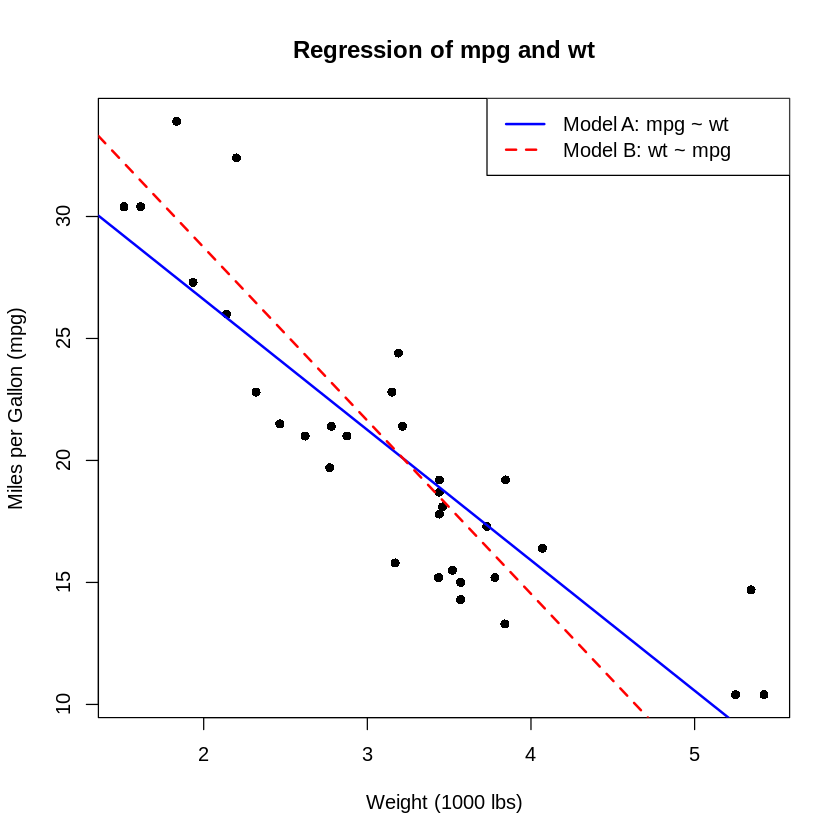

In [16]:
cat("PROBLEM 4\n")
data(mtcars)

model_a <- lm(mpg ~ wt, data = mtcars)
cat("Model A Summary (mpg dependent on wt):\n")
print(summary(model_a))

model_b <- lm(wt ~ mpg, data = mtcars)
cat("\nModel B Summary (wt dependent on mpg):\n")
print(summary(model_b))

plot(mtcars$wt, mtcars$mpg, main = "Regression of mpg and wt",
     xlab = "Weight (1000 lbs)", ylab = "Miles per Gallon (mpg)", pch = 16)

abline(model_a, col = "blue", lwd = 2)

a0 <- coef(model_b)[1]
a1 <- coef(model_b)[2]
abline(a = -a0/a1, b = 1/a1, col = "red", lwd = 2, lty = 2)

legend("topright", legend = c("Model A: mpg ~ wt", "Model B: wt ~ mpg"),
       col = c("blue", "red"), lwd = 2, lty = c(1, 2))

cat("\nInterpretations for Part (d)\n")
cat("Model A Slope: For every 1,000 lbs increase in weight, fuel efficiency decreases by ~5.34 mpg.\n")
cat("Model B Slope: For every 1 mpg increase, weight decreases by ~0.141 thousand lbs (141 lbs).\n")

PROBLEM 5
Quadratic Model Summary:

Call:
lm(formula = dist ~ speed + I(speed^2), data = cars)

Residuals:
    Min      1Q  Median      3Q     Max 
-28.720  -9.184  -3.188   4.628  45.152 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)
(Intercept)  2.47014   14.81716   0.167    0.868
speed        0.91329    2.03422   0.449    0.656
I(speed^2)   0.09996    0.06597   1.515    0.136

Residual standard error: 15.18 on 47 degrees of freedom
Multiple R-squared:  0.6673,	Adjusted R-squared:  0.6532 
F-statistic: 47.14 on 2 and 47 DF,  p-value: 5.852e-12


Estimated stopping distances at 45 mph and 80 mph:
       1        2 
245.9857 715.2727 

Linear Model Summary:

Call:
lm(formula = dist ~ speed, data = cars)

Residuals:
    Min      1Q  Median      3Q     Max 
-29.069  -9.525  -2.272   9.215  43.201 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -17.5791     6.7584  -2.601   0.0123 *  
speed         3.9324     0.4155   9.464 1.49e-12 ***
-

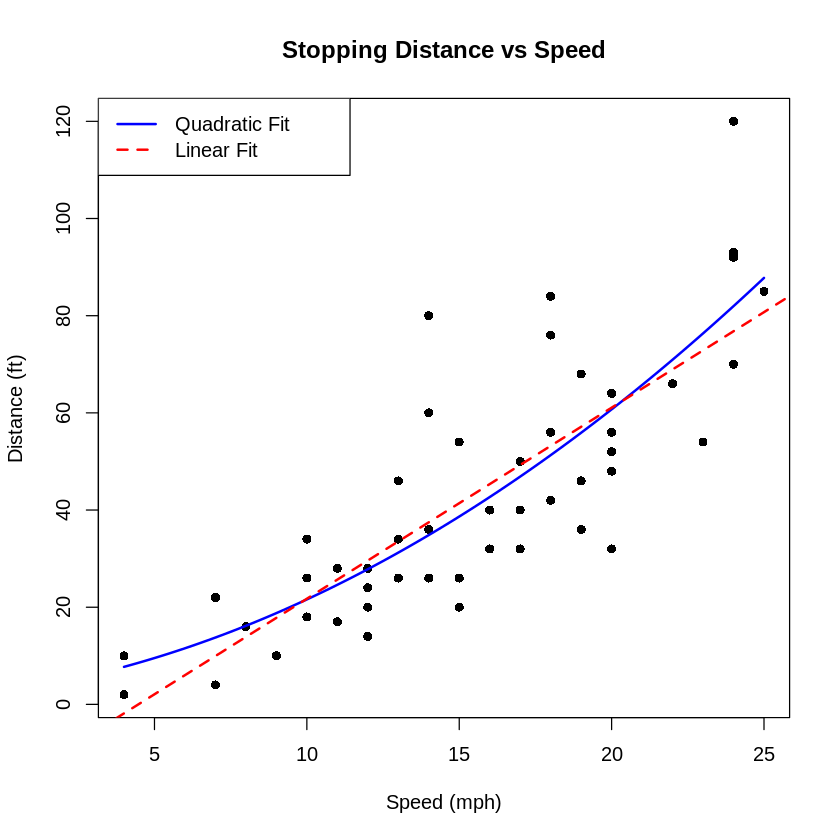

In [18]:
cat("PROBLEM 5\n")
data(cars)

plot(cars$speed, cars$dist, main = "Stopping Distance vs Speed",
     xlab = "Speed (mph)", ylab = "Distance (ft)", pch = 16)

quad_model <- lm(dist ~ speed + I(speed^2), data = cars)
cat("Quadratic Model Summary:\n")
print(summary(quad_model))

speed_seq <- seq(min(cars$speed), max(cars$speed), length.out = 100)
dist_pred_quad <- predict(quad_model, newdata = data.frame(speed = speed_seq))
lines(speed_seq, dist_pred_quad, col = "blue", lwd = 2)

new_speeds <- data.frame(speed = c(45, 80))
estimated_dists <- predict(quad_model, newdata = new_speeds)
cat("\nEstimated stopping distances at 45 mph and 80 mph:\n")
print(estimated_dists)

linear_model <- lm(dist ~ speed, data = cars)
cat("\nLinear Model Summary:\n")
print(summary(linear_model))

abline(linear_model, col = "red", lwd = 2, lty = 2)

legend("topleft", legend = c("Quadratic Fit", "Linear Fit"),
       col = c("blue", "red"), lwd = 2, lty = c(1, 2))

cat("\nANOVA Comparison (Linear vs Quadratic):\n")
print(anova(linear_model, quad_model))

cat("\nInterpretations for Part (e)\n")
cat("Model Comparison: The Multiple R-squared values are very similar (Linear: 0.6511, Quadratic: 0.6673).\n")
cat("Furthermore, the ANOVA test yields a p-value of 0.1364 (which is > 0.05).\n")
cat("This indicates that adding the quadratic term does not statistically significantly improve the fit over the simple linear model for this specific dataset.\n")